In this notebook, we will investigate the ART matrix and see if we can find a pressure domain PU matrix that matches the ART energy matrix, $\mathbf{S}$ exactly. The ART matrix is column-stochastic, i.e, 
$$
\begin{aligned}
\sum_h S_{h\to i \to j} &= 1 \quad \forall\, i,j \quad \text{(lossless)}, \\
\mathbf{1}^\top \mathbf{S} &= \mathbf{1}^\top.
\end{aligned}
$$

Now, we want to find a PU matrix, $\mathbf{H}(e^{j\omega})$ such that
$$\frac{1}{2 \pi} \int_0^{2\pi}|H_{ij}(e^{j\omega})|^2 d\omega = S_{ij}, \quad \mathbf{H}(e^{j\omega})\mathbf{H}(e^{-j\omega})^\top = \mathbf{I}$$

Note that $|\mathbf{H}(e^{j\omega})|^{\odot 2}$ is doubly stochastic. However, $\mathbf{S}$ is only column-stochastic. For the above equivalence to hold, $\mathbf{S}$ must be made doubly stochastic using the Sinkhorn-Knopp algorthm. However, for this $\mathbf{S}$ requires total support but that is unlikely due to the sparsity of the matrix.

1. First, we prune the matrix $\mathbf{S}$ to remove connections of patches that are not visible to each other. For an $\mathbf{S} \in \mathbb{R}^{+(N \times N)}$, if $k$ patches are not visible to each other then the matrix is pruned to be of size, $\mathbf{S}_{p} \in \mathbb{R}^{+(N-k) \times (N-k)}$.
2.  We run Sinkhorn-Knopp on the pruned matrix to get a doubly stochastic matrix, $\hat{\mathbf{S}}_p, \text{ s.t. } \mathbf{1}^\top\hat{\mathbf{S}}_p = \mathbf{1}^T,  \hat{\mathbf{S}}_p \mathbf{1} = \mathbf{1}.$
3.  We find the FIR PU matrix, $\mathbf{H}(z)$, s.t, $\int_{0}^{2\pi} |\mathbf{H}(e^{j\omega})|^{\odot 2}d \omega = \hat{\mathbf{S}}_p$.
4.  We operate TD-ART in the pressure domain with the FIR PU matrix.

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import scipy
import os
from pathlib import Path
from loguru import logger
from slope2noise.utils import db
import SDNPy.utils.MatrixMath as mm
import SDNPy.utils.visualize_room as vis

In [2]:
patch_area = 2.0
# environment_name = f'ERTD_generated_patch_area={patch_area:.1f}'
environment_name = 'ERTD_1_patch_per_wall'
environment_folder = os.path.join('..', 'environment', environment_name)
sample_rate = 44100

fig_path = Path('../../../Figures/ART/ERTD')
fig_path.mkdir(parents=True, exist_ok=True)

#### Read ART patching matrix and reflection matrix

In [3]:
# Read the .mtx file
art_reflect_matrix = scipy.io.mmread(f'{environment_folder}/ART_kernel_band_1.mtx')
art_patching_matrix = scipy.io.mmread(f'{environment_folder}/path_indexing.mtx')

# Convert to dense format if needed for visualization (optional)
art_dense_matrix = art_reflect_matrix.toarray()
art_patching_matrix_dense = art_patching_matrix.toarray()

num_non_zero_elems = np.count_nonzero(art_patching_matrix_dense)
assert art_dense_matrix.shape[0] == num_non_zero_elems

# Extract patch labels in mesh order from mesh.obj
mesh_obj_path = Path(environment_folder) / 'mesh.obj'
patch_labels = []
with open(mesh_obj_path, 'r', encoding='utf-8') as f:
    for line in f:
        line_no_comment = line.split('#', 1)[0].strip()
        if not line_no_comment.startswith('usemtl '):
            continue
        mat_name = line_no_comment.split()[1]
        if mat_name not in patch_labels:
            patch_labels.append(mat_name)

num_patches = art_patching_matrix_dense.shape[0]
assert len(patch_labels) == num_patches, (
    f'Expected {num_patches} patch labels from mesh.obj, found {len(patch_labels)}.'
)

#### Plot patching matrix - out of 256 total connections, 134 are valid

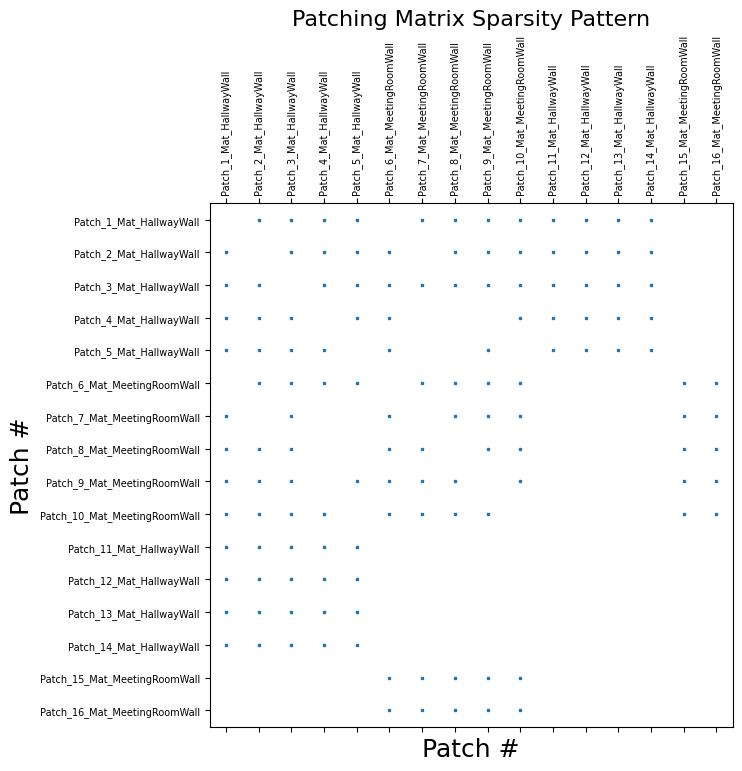

In [4]:
# Create a Spy plot to visualize sparsity
plt.figure(figsize=(9, 8))
plt.spy(art_patching_matrix, markersize=2)
plt.title('Patching Matrix Sparsity Pattern')
plt.xlabel('Patch #')
plt.ylabel('Patch #')
plt.xticks(range(num_patches), patch_labels, rotation=90, fontsize=7)
plt.yticks(range(num_patches), patch_labels, fontsize=7)
plt.tight_layout()
plt.savefig(f'{fig_path.resolve()}/{environment_name}_patching_matrix.png')
plt.show()

#### Plot the sparse ART reflection matrix and its pruned, dense version for each patch

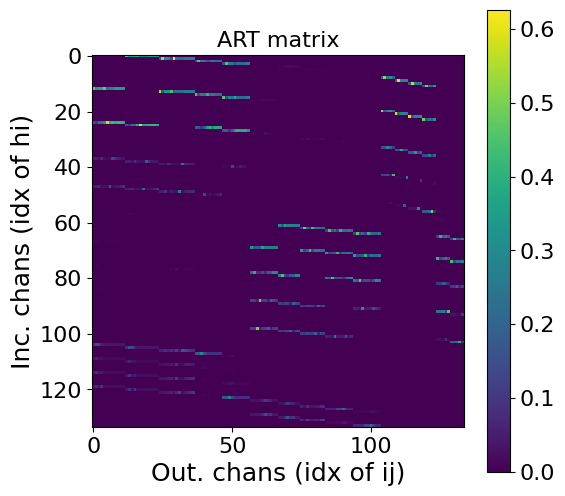

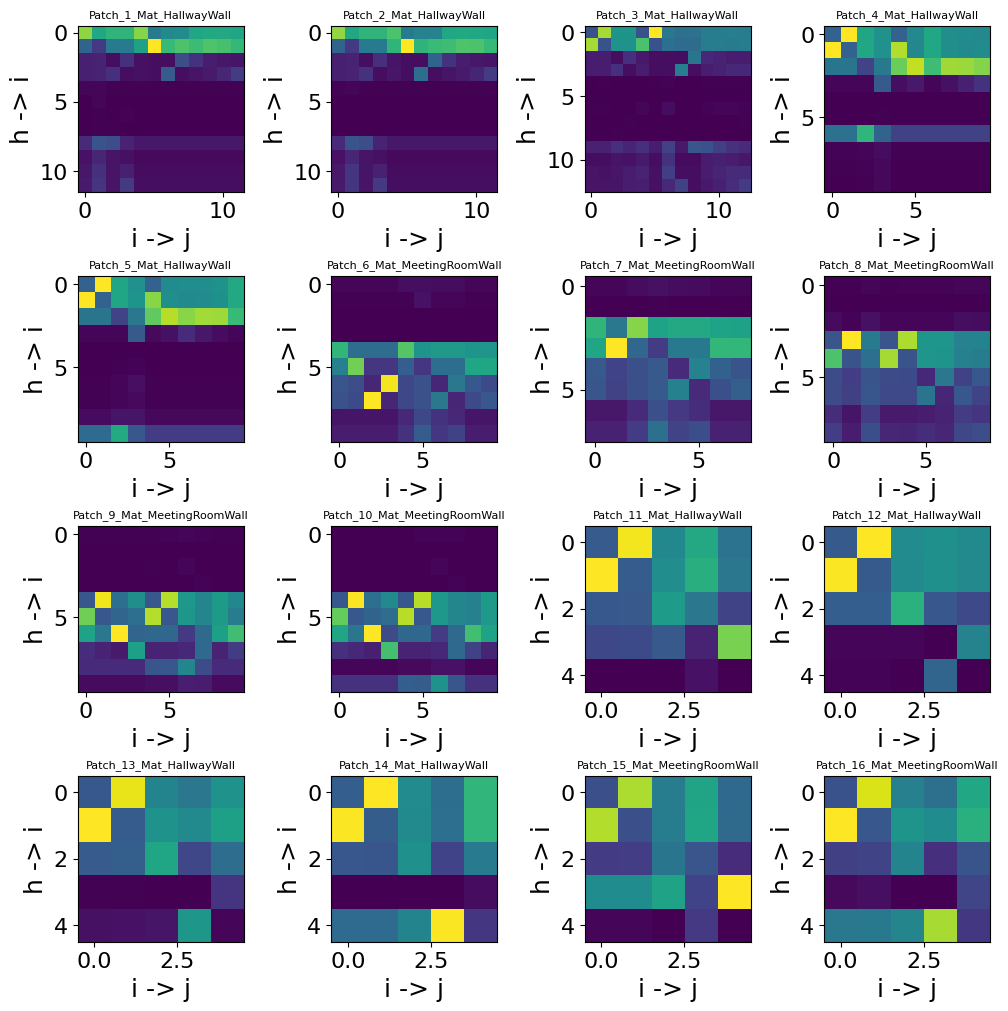

In [5]:
# Create a Heatmap for density
plt.figure(figsize=(6, 6))
plt.imshow(art_dense_matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title('ART matrix')
plt.xlabel('Out. chans (idx of ij)')
plt.ylabel('Inc. chans (idx of hi)')
plt.show()

art_matrix_pruned_list = mm.prune_tdart_matrix(art_dense_matrix, art_patching_matrix.copy())
fig, axes = plt.subplots(4, 4, figsize=(10, 10), constrained_layout=True)
for i, ax in enumerate(axes.flat):
    # make sure no zero elements in the matrices
    num_elems =  art_matrix_pruned_list[i].shape[0] * art_matrix_pruned_list[i].shape[1]
    assert np.count_nonzero(art_matrix_pruned_list[i]) - num_elems == 0
    ax.imshow(art_matrix_pruned_list[i], cmap='viridis', interpolation='nearest')
    ax.set_title(f"{patch_labels[i]}", fontsize=8)
    ax.set_xlabel("i -> j")
    ax.set_ylabel("h -> i")
    
plt.savefig(f'{fig_path.resolve()}/{environment_name}_stochastic_art_matrices.png')    
plt.show()

#### Plot the doubly stochastic Sinkhorn Knopp versions of the smaller matrices

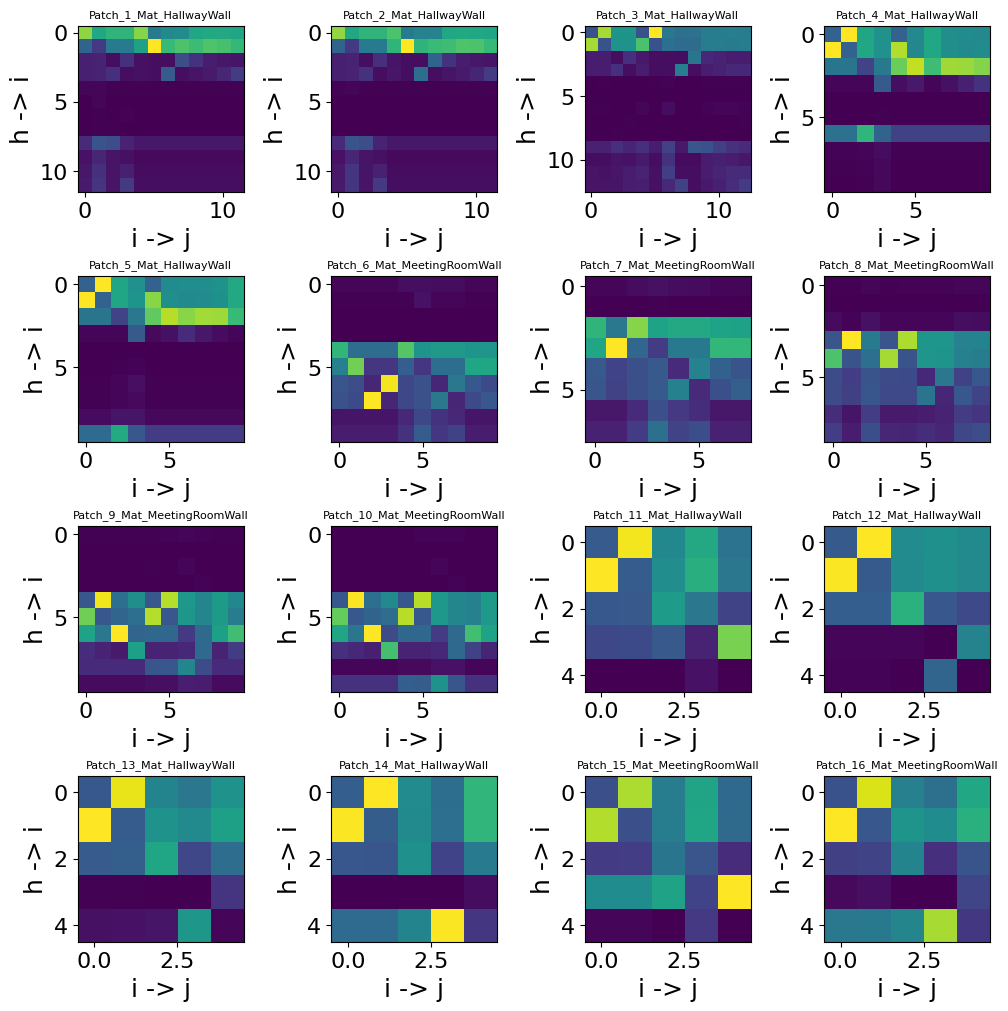

In [6]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10), constrained_layout=True)
art_matrix_pruned_double_stochastic = []

for i, ax in enumerate(axes.flat):
    try:
        cur_double_stochastic = mm.sinkhornKnopp(art_matrix_pruned_list[i], verbose=False)
    except AssertionError as e:
        logger.error("Sinkhorn Knopp failed")
    art_matrix_pruned_double_stochastic.append(cur_double_stochastic)
    assert np.allclose(np.sum(art_matrix_pruned_double_stochastic[i], axis=0), np.ones(art_matrix_pruned_double_stochastic[i].shape[0]))
    assert np.allclose(np.sum(art_matrix_pruned_double_stochastic[i], axis=1), np.ones(art_matrix_pruned_double_stochastic[i].shape[1]))
    ax.imshow(art_matrix_pruned_list[i], cmap='viridis', interpolation='nearest')
    ax.set_title(f"{patch_labels[i]}", fontsize=8)
    ax.set_xlabel("i -> j")
    ax.set_ylabel("h -> i")

plt.savefig(f'{fig_path.resolve()}/{environment_name}_doubly_stochastic_art_matrices.png')    
plt.show()

#### Find the FIR PU matrix whose average power gives the desired doubly stochastic matrix

This is the most challenging part, 
   - We do a decomposition:
   $$\hat{\mathbf{S}}_p = T_1 T_2 \ldots T_K,$$ $$T_r = t_r I + (1-t_r) Q$$ where Q is a permutation matrix to exchange two elements of a vector, eg to exchange (i, j) elements, set $Q = I$ and then exchange ith and jth rows (or columns).
i.e., $T_r$ is identity except on a $2 \times 2$ block, $\begin{bmatrix} t_r & 1-t_r \\ 1-t_r & t_r\end{bmatrix}, 0 \leq t_r \leq 1$.  Now, $T_r = |G_r|^{\odot 2}$ where $G_r$ is a Givens rotation matrix.
        - This decomposition is tricky. We fix $K$. Then we find $K=\binom{N}{2}$ unique possible permutations of the $2 \times 2$ block with $K$ unique $t_r$ values. We use non-linear least squares to find $$\arg \min_{t_1, \ldots, t_K} ||\hat{\mathbf{S}}_p - T_1(t_1) T_2(t_2) \ldots T_K(t_K)||^2_F,$$ where $0 \leq t_r \leq 1$, but we must test for $K$ possible pairs of $(i, j)$ while constructing the T-transform matrix for each $r$.
        - We use n_restarts with different sets of initial $t_r$ and different permutations of $T_r$ to give our optimisation problem a better chance at converging.
   - Now, we can build $$\mathbf{H}(z) = G_1 D_1(z) G_2 D_2(z) \ldots G_K,$$ where $D_r(z) = \text{diag}(z^{d_{r,1}}, \ldots, z^{d_{r,N-k}})$.
   - Note that,$$\frac{1}{2 \pi} \int_0^{2\pi}|\mathbf{H}(e^{j\omega})|^{\odot 2} d\omega  = |G_1|^{\odot 2} |G_2|^{\odot 2} \ldots |G_{K}|^{\odot 2} = \hat{\mathbf{S}}_p$$. This holds as long as the delays $d_{r, n}$ are all pairwise distinct.
   - This is because $H_{ij}(e^{j\omega}) = \sum_p \alpha_p e^{-j\omega \tau_p}$, where $\tau_p$ is the total accumulated delay along that path, i.e, $\tau_p = \sum_{k=1}^K \omega_{k, c_k(p)}$ and $\alpha_p$ is the product of the Givens coefficients along that path. Here, $c_k(p)$ is a path such that $c_0(p) = j$, and $c_K(p) = i$. Therefore,
     $$\frac{1}{2 \pi} \int_0^{2\pi}|H_{ij}(e^{j\omega})|^2 d\omega = \sum_p |\alpha_p|^2 + \sum_{p \neq q} \alpha_p \alpha_q \frac{1}{2 \pi} \int_{0}^{2\pi} e^{-j\omega(\tau_p - \tau_q)} d\omega.$$ The cross-terms vanish if $\tau_p \neq \tau_q$.
   - A sufficient condition is to choose $D_k(z) = \text{diag}(1, \ldots, z^{-2^{k-1}}, \ldots, 1)$. More generally, $d_{r, i} > \sum_{\ell=1}^{r-1} \max_{m} d_{\ell, m}$. This means: every delay used at stage r is larger than the largest possible total delay that could have accumulated from all previous stages.

#### Convert the doubly stochastic matrices to PU matrices - use non-linear least squares for T-transform factorisation

2026-05-14 14:12:10.456 | DEBUG    | SDNPy.utils.MatrixMath:fit_t_transform_factorization:434 - Best T-transform fit with 66 stages has Frobenius error 1.369e-01
2026-05-14 14:12:10.543 | INFO     | __main__:<module>:23 - Doubly stochastic reconstruction error: -18.5312 dB
2026-05-14 14:12:10.547 | INFO     | __main__:<module>:24 - PU reconstruction error: -8.5826 dB
2026-05-14 14:12:10.547 | INFO     | __main__:<module>:25 - Time taken: 48.697s
2026-05-14 14:13:19.076 | DEBUG    | SDNPy.utils.MatrixMath:fit_t_transform_factorization:434 - Best T-transform fit with 66 stages has Frobenius error 1.402e-01
2026-05-14 14:13:19.097 | INFO     | __main__:<module>:23 - Doubly stochastic reconstruction error: -18.4252 dB
2026-05-14 14:13:19.097 | INFO     | __main__:<module>:24 - PU reconstruction error: -9.0430 dB
2026-05-14 14:13:19.098 | INFO     | __main__:<module>:25 - Time taken: 66.696s
2026-05-14 14:15:27.897 | DEBUG    | SDNPy.utils.MatrixMath:fit_t_transform_factorization:434 - Best

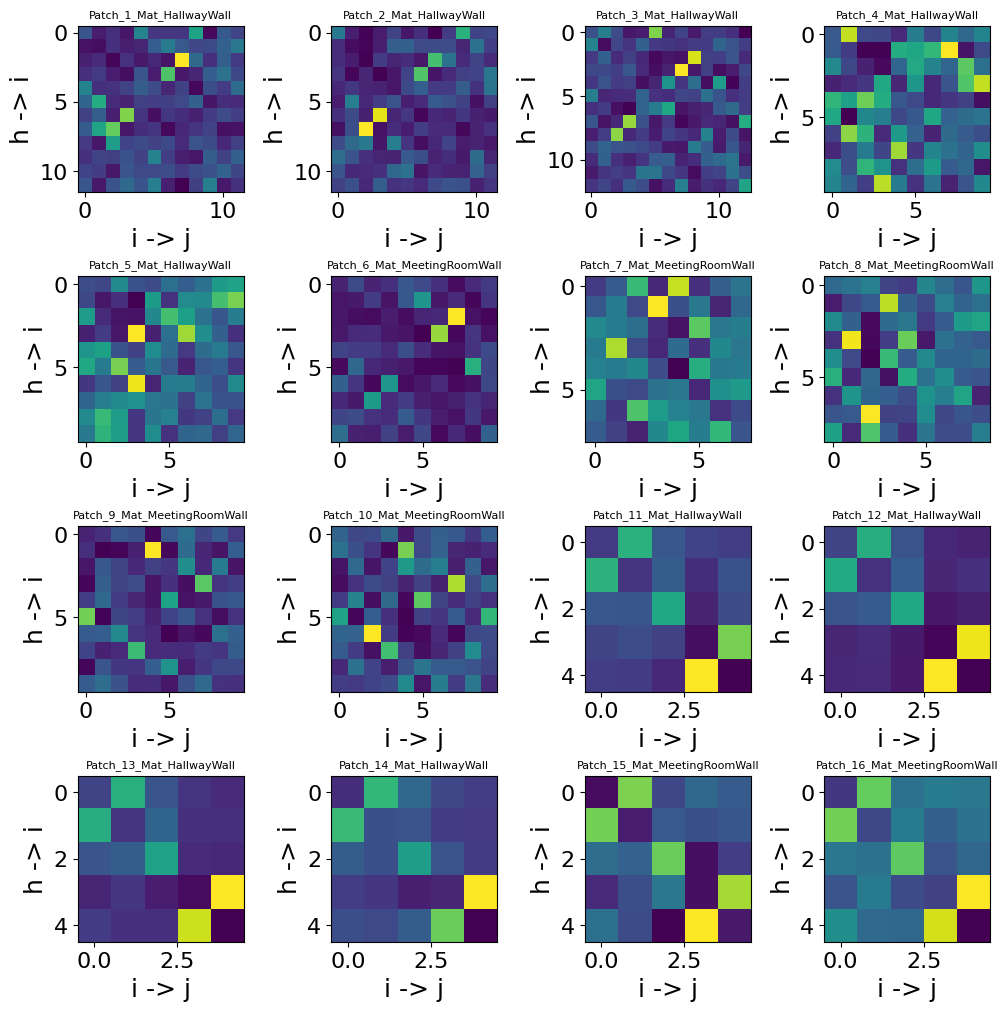

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10), constrained_layout=True)
art_matrix_pu_list = []
for i, ax in enumerate(axes.flat):
    try:
        cur_art_ds_matrix = art_matrix_pruned_double_stochastic[i]
        cur_mat_num_rows = cur_art_ds_matrix.shape[0]
        start_time = time.perf_counter()
        cur_art_pu_matrix, info = mm.doubly_stochastic_to_paraunitary(cur_art_ds_matrix, 
                                                                      factor_tol=1e-6,
                                                                      factor_method='nls',
                                                                      n_restarts=8,
                                                                      exact_delay_max_taps=2048,
                                                                      return_info=True)
        end_time = time.perf_counter()
        execution_time = end_time - start_time
        
        art_matrix_pu_list.append(cur_art_pu_matrix) 
        ax.imshow(info["average_energy"], cmap='viridis', interpolation='nearest')
        ax.set_title(f"{patch_labels[i]}", fontsize=8)
        ax.set_xlabel("i -> j")
        ax.set_ylabel("h -> i")
        
        logger.info(f"Doubly stochastic reconstruction error: {db(info['factor_error']):.4f} dB")
        logger.info(f"PU reconstruction error: {db(info['average_energy_error']):.4f} dB")
        logger.info(f"Time taken: {execution_time:.3f}s")
        
        assert db(info['factor_error']) <= -6, "Doubly stochastic reconstriction failed"
        assert db(info['average_energy_error']) <= -6, "PU reconstriction failed"
        assert info["is_paraunitary"], "Resulting matrix not unitary"
    except AssertionError as e:
        logger.error(f"PU reconstruction failed for {patch_labels[i]} scattering matrix of size {cur_mat_num_rows} x {cur_mat_num_rows}")
        continue
    

    
    # plot polynomial matrix
    vis.plot_poly_mats_overlay([cur_art_pu_matrix], 
                               labels=[patch_labels[i]], 
                               fs=sample_rate, 
                               title=f"{patch_labels[i]}, DS recons err ={db(info['factor_error']):.4f}dB",
                               save_path = f'{fig_path.resolve()}/{environment_name}_pu_art_matrix_{patch_labels[i]}_nls.png',
                              )


fig.savefig(f'{fig_path.resolve()}/{environment_name}_pu_nls_avg_energy_art_matrices.png')    
plt.show()


#### Convert the doubly stochastic matrices to PU matrices - use CGD for T-transform factorisation

2026-05-14 14:18:55.276 | DEBUG    | SDNPy.utils.MatrixMath:fit_t_transform_factorization:434 - Best T-transform fit with 66 stages has Frobenius error 5.733e-01
2026-05-14 14:18:55.296 | INFO     | __main__:<module>:25 - Doubly stochastic reconstruction error: -6.0937 dB
2026-05-14 14:18:55.296 | INFO     | __main__:<module>:26 - PU reconstruction error: -3.6024 dB
2026-05-14 14:18:55.297 | INFO     | __main__:<module>:27 - Time taken: 30.412s
2026-05-14 14:18:55.297 | ERROR    | __main__:<module>:35 - PU reconstruction failed for Patch_1_Mat_HallwayWall scattering matrix of size 12 x 12
2026-05-14 14:19:26.783 | DEBUG    | SDNPy.utils.MatrixMath:fit_t_transform_factorization:434 - Best T-transform fit with 66 stages has Frobenius error 6.097e-01
2026-05-14 14:19:26.799 | INFO     | __main__:<module>:25 - Doubly stochastic reconstruction error: -5.6614 dB
2026-05-14 14:19:26.799 | INFO     | __main__:<module>:26 - PU reconstruction error: -3.4824 dB
2026-05-14 14:19:26.799 | INFO     

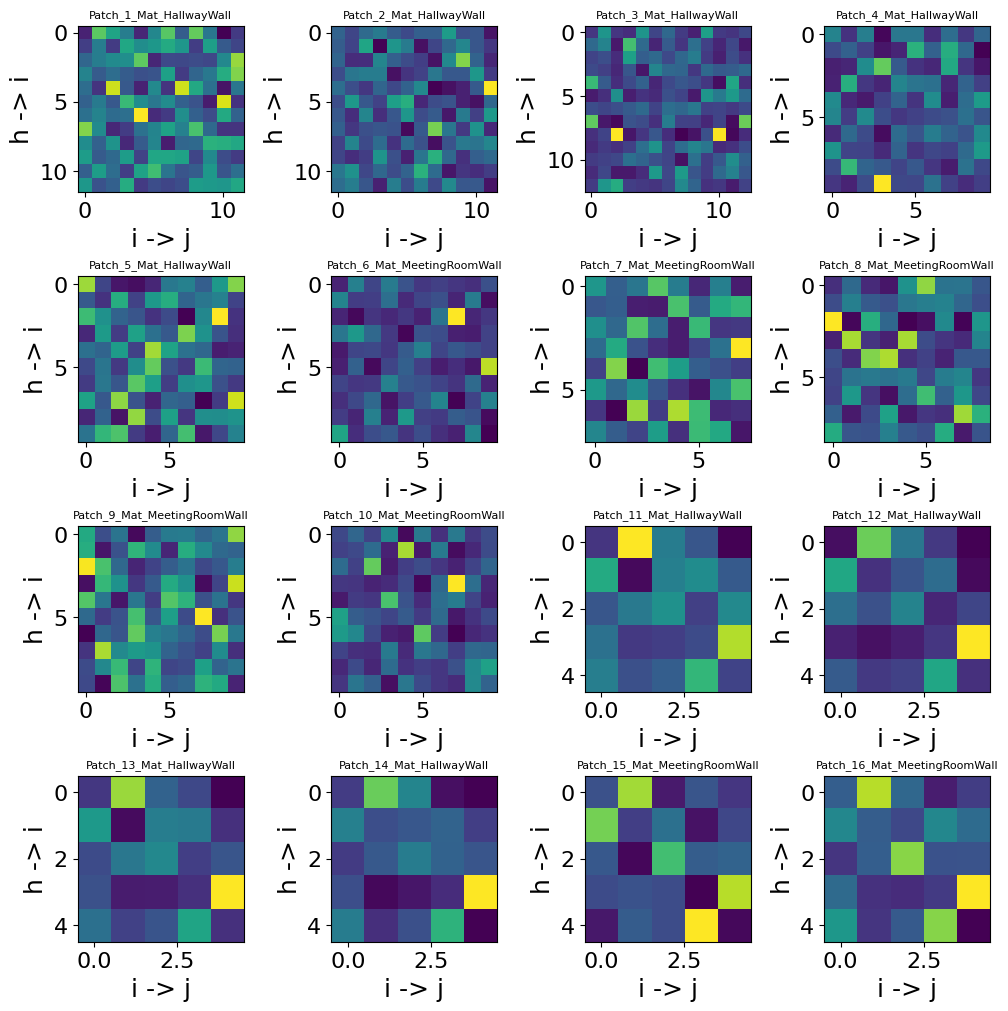

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10), constrained_layout=True)
art_matrix_pu_list = []
for i, ax in enumerate(axes.flat):
    try:
        cur_art_ds_matrix = art_matrix_pruned_double_stochastic[i]
        cur_mat_num_rows = cur_art_ds_matrix.shape[0]
        start_time = time.perf_counter()

        cur_art_pu_matrix, info = mm.doubly_stochastic_to_paraunitary(cur_art_ds_matrix, 
                                                                      factor_tol=1e-6,
                                                                      factor_method='cgd',
                                                                      n_restarts=8,
                                                                      exact_delay_max_taps=2048,
                                                                      return_info=True,
                                                                     )
        end_time = time.perf_counter()
        execution_time = end_time - start_time
        
        art_matrix_pu_list.append(cur_art_pu_matrix)        
        ax.imshow(info["average_energy"], cmap='viridis', interpolation='nearest')
        ax.set_title(f"{patch_labels[i]}", fontsize=8)
        ax.set_xlabel("i -> j")
        ax.set_ylabel("h -> i")
            
        logger.info(f"Doubly stochastic reconstruction error: {db(info['factor_error']):.4f} dB")
        logger.info(f"PU reconstruction error: {db(info['average_energy_error']):.4f} dB")
        logger.info(f"Time taken: {execution_time:.3f}s")
        

        assert db(info['factor_error']) <= -6, "Doubly stochastic reconstriction failed"
        assert db(info['average_energy_error']) <= -6, "PU reconstriction failed"
        assert info["is_paraunitary"], "Resulting matrix not unitary"

    except AssertionError as e:
        logger.error(f"PU reconstruction failed for {patch_labels[i]} scattering matrix of size {cur_mat_num_rows} x {cur_mat_num_rows}")
        continue



    vis.plot_poly_mats_overlay([cur_art_pu_matrix], 
                                   labels=[patch_labels[i]], 
                                   fs=sample_rate, 
                                   title=f"{patch_labels[i]}, DS recons err ={db(info['factor_error']):.4f}dB",
                                   save_path = f'{fig_path.resolve()}/{environment_name}_pu_art_matrix_{patch_labels[i]}_cgd.png',
                              )
fig.savefig(f'{fig_path.resolve()}/{environment_name}_pu_cgd_avg_energy_art_matrices.png')    
plt.show()

#### Convert doubly stochastic matrices to closest SA unitary matrix and observe error

2026-05-14 16:30:22.059 | INFO     | __main__:<module>:17 - SA Unitary reconstruction error: 16.7849 dB
2026-05-14 16:30:22.062 | INFO     | __main__:<module>:18 - Time taken: 0.099s
2026-05-14 16:30:22.121 | INFO     | __main__:<module>:17 - SA Unitary reconstruction error: 16.3672 dB
2026-05-14 16:30:22.122 | INFO     | __main__:<module>:18 - Time taken: 0.055s
2026-05-14 16:30:22.180 | INFO     | __main__:<module>:17 - SA Unitary reconstruction error: 17.3863 dB
2026-05-14 16:30:22.181 | INFO     | __main__:<module>:18 - Time taken: 0.058s
2026-05-14 16:30:22.218 | INFO     | __main__:<module>:17 - SA Unitary reconstruction error: 13.4964 dB
2026-05-14 16:30:22.219 | INFO     | __main__:<module>:18 - Time taken: 0.037s
2026-05-14 16:30:22.256 | INFO     | __main__:<module>:17 - SA Unitary reconstruction error: 12.6121 dB
2026-05-14 16:30:22.256 | INFO     | __main__:<module>:18 - Time taken: 0.037s
2026-05-14 16:30:22.295 | INFO     | __main__:<module>:17 - SA Unitary reconstruction

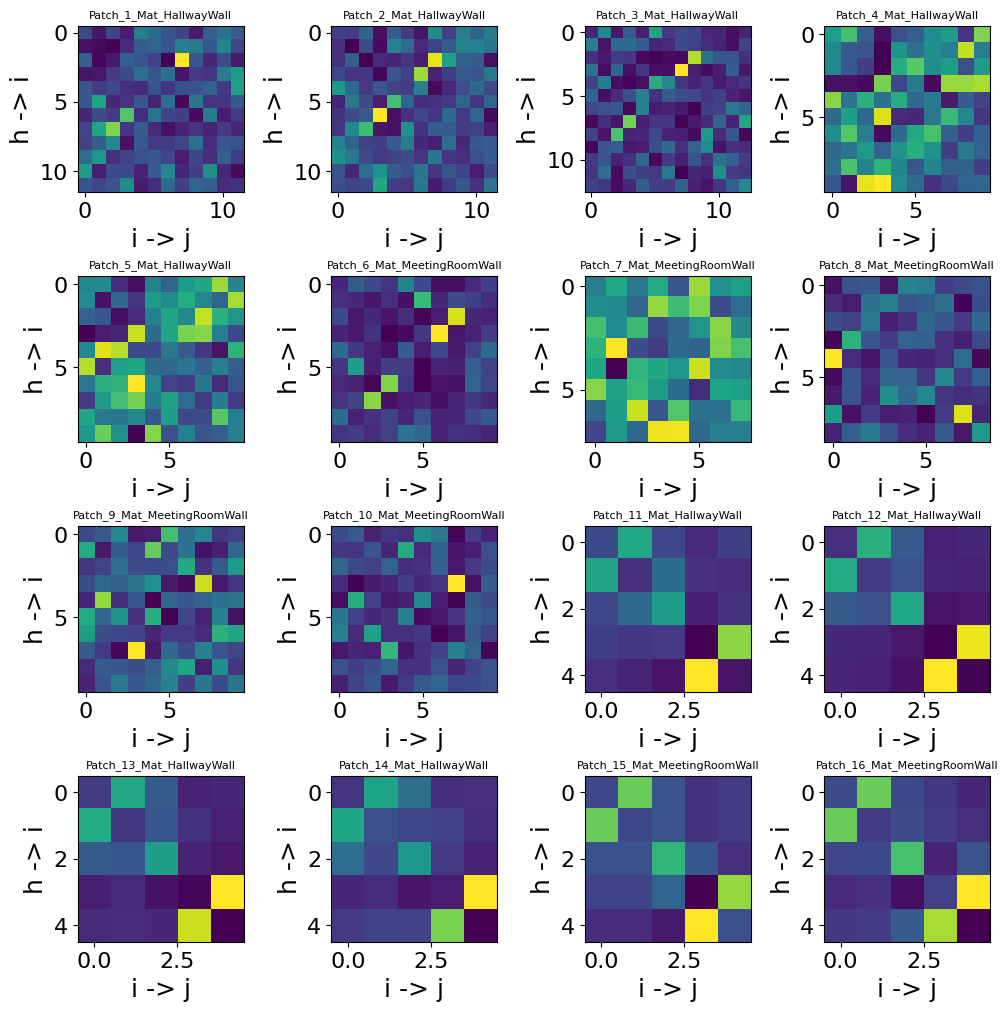

In [11]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10), constrained_layout=True)
art_matrix_sa_unitary_list = []

for i, ax in enumerate(axes.flat):
    try:
        cur_art_ds_matrix = art_matrix_pruned_double_stochastic[i]
        cur_mat_num_rows = cur_art_ds_matrix.shape[0]
        start_time = time.perf_counter()

        cur_art_sa_unit_matrix  = mm.closestSignAgnosticOrthonormal(np.sqrt(cur_art_ds_matrix))
        end_time = time.perf_counter()
        execution_time = end_time - start_time
        
        art_matrix_sa_unitary_list.append(cur_art_sa_unit_matrix)
        rel_err = np.linalg.norm(np.abs(cur_art_ds_matrix - cur_art_sa_unit_matrix**2) / cur_art_ds_matrix, ord='fro')

        logger.info(f"SA Unitary reconstruction error: {db(rel_err):.4f} dB")
        logger.info(f"Time taken: {execution_time:.3f}s")

    except AssertionError as e:
        logger.error(f"SA unitary reconstruction failed for {patch_labels[i]} scattering matrix of size {cur_mat_num_rows} x {cur_mat_num_rows}")
        continue

    ax.imshow(art_matrix_sa_unitary_list[i]**2, cmap='viridis', interpolation='nearest')
    ax.set_title(f"{patch_labels[i]}", fontsize=8)
    ax.set_xlabel("i -> j")
    ax.set_ylabel("h -> i")

plt.savefig(f'{fig_path.resolve()}/{environment_name}_sa_unitary_squared_art_matrices.png')    
plt.show()

### Observations
- PU reconstruction error is greater than doubly stochastic reconstruction error.
- Doubly stochastic reconstruction error is smaller for smaller matrices
- Non linear LS is slower but gives better local minima for finding T-transform parameters.
- Both PU reconstruction methods outperform SA unitary approximation in terms of Frobenius error.